# 02_features.ipynb — Feature Extraction and Validation

**Purpose:** Extract 131-feature vectors (128 band-power + 3 FAA) for all 1280 trials. Validate on a single trial first, then run on the full dataset. Save feature matrix and feature names to `results/`.

**Inputs:**  `results/X_eeg.npy`, `results/X_peripheral.npy`

**Outputs:** `results/X_features.npy` (1280, 131), `results/X_peripheral_features.npy` (1280, 8), `results/feature_names.npy`

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from features import (
    extract_trial, extract_all, extract_peripheral,
    feature_names, BANDS, CHANNEL_NAMES, FAA_PAIRS,
    N_FEATURES, N_BP_FEATURES,
)

# Load saved arrays from 01_data.ipynb
X_eeg        = np.load('../results/X_eeg.npy')
X_peripheral = np.load('../results/X_peripheral.npy')

print(f"X_eeg shape:        {X_eeg.shape}")
print(f"X_peripheral shape: {X_peripheral.shape}")

X_eeg shape:        (1280, 32, 7680)
X_peripheral shape: (1280, 8, 7680)


## 1. Single-trial sanity check
Run `extract_trial` on one trial before touching the full dataset.

In [2]:
trial_features = extract_trial(X_eeg[0])  # (131,)

print(f"Feature vector shape: {trial_features.shape}  — expected (131,)")
print(f"Any NaN: {np.isnan(trial_features).any()}")
print(f"Any Inf: {np.isinf(trial_features).any()}")

# Band-power features (first 128) must all be non-negative (integrated PSD)
bp = trial_features[:N_BP_FEATURES]
faa = trial_features[N_BP_FEATURES:]

print(f"\nBand-power features [{N_BP_FEATURES}]:")
print(f"  min={bp.min():.4f}  max={bp.max():.4f}  — must be >= 0")
assert (bp >= 0).all(), "Negative band-power values — check extract_trial"
print(f"  Non-negativity check: PASSED")

print(f"\nFAA features [3]: {faa}")
print(f"  (log-difference, sign reflects hemispheric asymmetry — can be negative)")

Feature vector shape: (131,)  — expected (131,)
Any NaN: False
Any Inf: False

Band-power features [128]:
  min=0.2842  max=9.6900  — must be >= 0
  Non-negativity check: PASSED

FAA features [3]: [ 0.17704765 -0.02562466  0.03034582]
  (log-difference, sign reflects hemispheric asymmetry — can be negative)


In [3]:
# Print first few named features to confirm ordering matches expectation
names = feature_names()
assert len(names) == N_FEATURES, f"Expected {N_FEATURES} names, got {len(names)}"

print("First 8 features (expect Fp1_theta through Fp1_gamma, AF3_theta, AF3_alpha):")
for i in range(8):
    print(f"  [{i:3d}] {names[i]:<20} = {trial_features[i]:.4f}")

print("\nLast 3 features (FAA):")
for i in range(N_BP_FEATURES, N_FEATURES):
    print(f"  [{i:3d}] {names[i]:<30} = {trial_features[i]:.4f}")

First 8 features (expect Fp1_theta through Fp1_gamma, AF3_theta, AF3_alpha):
  [  0] Fp1_theta            = 3.9735
  [  1] Fp1_alpha            = 3.8871
  [  2] Fp1_beta             = 5.7781
  [  3] Fp1_gamma            = 0.7589
  [  4] AF3_theta            = 5.2566
  [  5] AF3_alpha            = 4.4265
  [  6] AF3_beta             = 6.5434
  [  7] AF3_gamma            = 0.6927

Last 3 features (FAA):
  [128] FAA_Fp1_Fp2                    = 0.1770
  [129] FAA_AF3_AF4                    = -0.0256
  [130] FAA_F3_F4                      = 0.0303


## 2. Visual sanity checks on a single subject

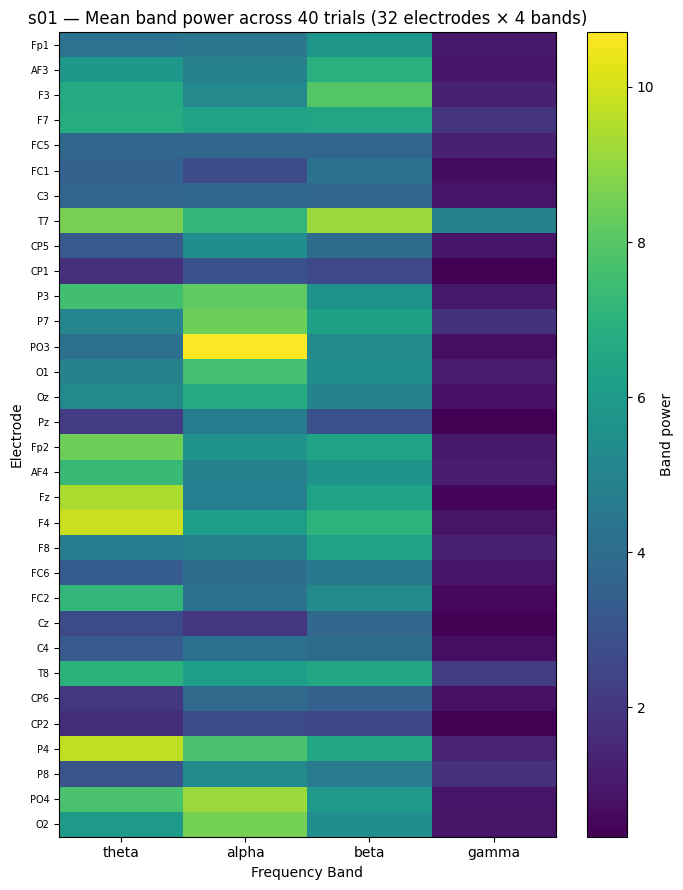

In [4]:
# Extract features for subject 1 (trials 0-39) to inspect distributions before full run
X_s01 = np.array([extract_trial(X_eeg[i]) for i in range(40)])  # (40, 131)

band_names = list(BANDS.keys())
n_bands    = len(band_names)

# Band power heatmap: mean across 40 trials, shape (32 electrodes, 4 bands)
bp_matrix = X_s01[:, :N_BP_FEATURES].mean(axis=0).reshape(32, n_bands)  # (32, 4)

fig, ax = plt.subplots(figsize=(7, 9))
im = ax.imshow(bp_matrix, aspect='auto', cmap='viridis')
ax.set_xticks(range(n_bands))
ax.set_xticklabels(band_names)
ax.set_yticks(range(32))
ax.set_yticklabels(CHANNEL_NAMES, fontsize=7)
ax.set_xlabel('Frequency Band')
ax.set_ylabel('Electrode')
ax.set_title('s01 — Mean band power across 40 trials (32 electrodes × 4 bands)')
plt.colorbar(im, ax=ax, label='Band power')
plt.tight_layout()
plt.savefig('../results/figures/s01_band_power_heatmap.png', dpi=150)
plt.show()

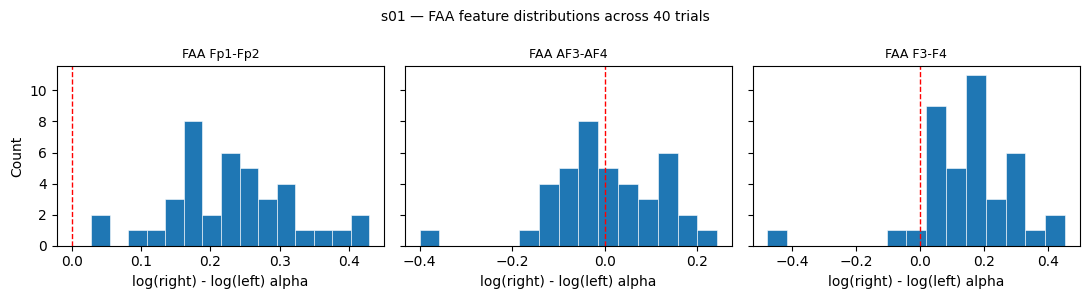

FAA summary (s01):
  FAA Fp1-Fp2: mean=0.230  std=0.090  range=[0.028, 0.430]
  FAA AF3-AF4: mean=0.004  std=0.116  range=[-0.400, 0.243]
  FAA F3-F4: mean=0.156  std=0.150  range=[-0.477, 0.454]


In [5]:
# FAA values across 40 trials for subject 1
# Expect values centered near 0, plausible range roughly -2 to +2
faa_s01 = X_s01[:, N_BP_FEATURES:]  # (40, 3)
faa_labels = [f"FAA {CHANNEL_NAMES[l]}-{CHANNEL_NAMES[r]}" for l, r in FAA_PAIRS]

fig, axes = plt.subplots(1, 3, figsize=(11, 3), sharey=True)
for i, ax in enumerate(axes):
    ax.hist(faa_s01[:, i], bins=15, edgecolor='white', linewidth=0.4)
    ax.axvline(0, color='red', linewidth=1, linestyle='--')
    ax.set_title(faa_labels[i], fontsize=9)
    ax.set_xlabel('log(right) - log(left) alpha')

axes[0].set_ylabel('Count')
fig.suptitle('s01 — FAA feature distributions across 40 trials', fontsize=10)
plt.tight_layout()
plt.savefig('../results/figures/s01_faa_distributions.png', dpi=150)
plt.show()

print("FAA summary (s01):")
for i, label in enumerate(faa_labels):
    print(f"  {label}: mean={faa_s01[:,i].mean():.3f}  std={faa_s01[:,i].std():.3f}  "
          f"range=[{faa_s01[:,i].min():.3f}, {faa_s01[:,i].max():.3f}]")

## 3. Extract features for all 1280 trials

In [6]:
print("Extracting EEG features for all 1280 trials — this takes a few minutes...")
X_features = extract_all(X_eeg)  # (1280, 131)
print(f"Done. Shape: {X_features.shape}")

# Validate
assert X_features.shape == (1280, N_FEATURES)
assert not np.isnan(X_features).any(), "NaN in feature matrix"
assert not np.isinf(X_features).any(), "Inf in feature matrix"
assert (X_features[:, :N_BP_FEATURES] >= 0).all(), "Negative band-power in full matrix"
print("Validation passed.")

print(f"\nFull feature matrix stats:")
print(f"  Band-power: min={X_features[:,:N_BP_FEATURES].min():.4f}  "
      f"max={X_features[:,:N_BP_FEATURES].max():.4f}")
print(f"  FAA:        min={X_features[:,N_BP_FEATURES:].min():.4f}  "
      f"max={X_features[:,N_BP_FEATURES:].max():.4f}")

Extracting EEG features for all 1280 trials — this takes a few minutes...
Done. Shape: (1280, 131)
Validation passed.

Full feature matrix stats:
  Band-power: min=0.2485  max=54355.1402
  FAA:        min=-3.7308  max=5.0092


In [7]:
# Extract peripheral features
X_peripheral_features = extract_peripheral(X_peripheral)  # (1280, 8)

assert X_peripheral_features.shape == (1280, 8)
assert not np.isnan(X_peripheral_features).any()
assert not np.isinf(X_peripheral_features).any()
print(f"Peripheral features shape: {X_peripheral_features.shape}  — expected (1280, 8)")
print(f"Value range: [{X_peripheral_features.min():.2f}, {X_peripheral_features.max():.2f}]")
print("(Large range expected — different physical units across channels; StandardScaler handles this in the LOSO loop)")

Peripheral features shape: (1280, 8)  — expected (1280, 8)
Value range: [-239784.37, 908541.61]
(Large range expected — different physical units across channels; StandardScaler handles this in the LOSO loop)


## 4. Cross-trial distribution check

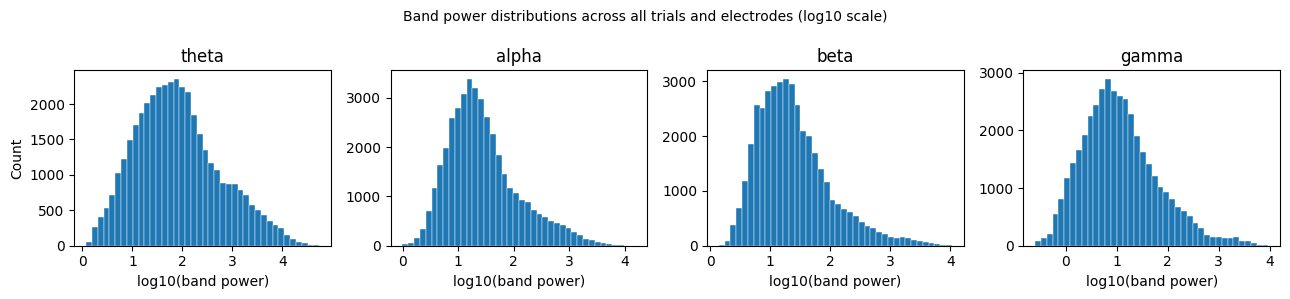

In [8]:
# Band power distributions across all 1280 trials, per band
# Each band has 32 electrode values per trial; pool them all
n_bands    = len(BANDS)
band_names = list(BANDS.keys())

bp_all = X_features[:, :N_BP_FEATURES].reshape(1280, 32, n_bands)  # (1280, 32, 4)

fig, axes = plt.subplots(1, 4, figsize=(13, 3))
for b, (ax, band) in enumerate(zip(axes, band_names)):
    vals = bp_all[:, :, b].flatten()
    ax.hist(np.log10(vals + 1e-10), bins=40, edgecolor='white', linewidth=0.3)
    ax.set_title(band)
    ax.set_xlabel('log10(band power)')
    ax.set_ylabel('Count' if b == 0 else '')

fig.suptitle('Band power distributions across all trials and electrodes (log10 scale)', fontsize=10)
plt.tight_layout()
plt.savefig('../results/figures/band_power_distributions.png', dpi=150)
plt.show()

## 5. Save to results/

In [9]:
names = feature_names()

np.save('../results/X_features.npy',            X_features)
np.save('../results/X_peripheral_features.npy', X_peripheral_features)
np.save('../results/feature_names.npy',         np.array(names))

print("Saved:")
for fname in ['X_features', 'X_peripheral_features', 'feature_names']:
    path = Path(f'../results/{fname}.npy')
    print(f"  {path}  ({path.stat().st_size / 1e6:.1f} MB)")

print(f"\nReady for 03_model.ipynb.")

Saved:
  ../results/X_features.npy  (1.3 MB)
  ../results/X_peripheral_features.npy  (0.1 MB)
  ../results/feature_names.npy  (0.0 MB)

Ready for 03_model.ipynb.
